# 🧠 PathVQA-Lite | Notebook 2 of 3
## Multimodal VQA Model Architecture & Training

---

### 🎯 Notebook Objective

This notebook builds and trains the **CrossAttentionVQA** model — a research-grade multimodal architecture that fuses pathology image features with clinical question representations to produce answers.

**What we build:**
1. CLIP baseline (zero-shot similarity scoring — establishes lower bound)
2. `VisualEncoder` — frozen CLIP ViT with optional unfreezing schedule
3. `TextEncoder` — CLIP text tower + BiomedBERT option
4. `CrossAttentionFusion` — the core image-language alignment module
5. `HybridAnswerHead` — binary classifier + open-ended classifier (question-type routed)
6. `PathVQAModel` — full end-to-end model with forward pass + shape annotations
7. Training engine — AMP, gradient accumulation, cosine schedule, early stopping
8. Checkpoint management — resume from Drive on runtime crash

---

### 🏗️ Architecture Philosophy

> **Why cross-attention instead of simple concatenation?**

Simple concatenation (`[image_feat; text_feat] → MLP`) treats the two modalities as independent. But in medical VQA, the question **actively queries** the image:

- *"Are mitotic figures present?"* → the model must attend to high-frequency nuclear regions
- *"What color are the nuclei?"* → the model must attend to chromatic channels specifically

Cross-attention lets text tokens **query image patch tokens**, producing question-conditioned visual representations. This is the same mechanism as in BLIP, Flamingo, and Med-PaLM.

---

### 💾 VRAM Budget (T4 / A100 guidance)

| Config | VRAM Usage | Fits on |
|---|---|---|
| CLIP frozen + small fusion | ~4 GB | T4 (Colab free) |
| CLIP partial unfreeze | ~8 GB | T4 with AMP |
| CLIP full unfreeze | ~14 GB | A100 (Colab Pro) |
| Batch 32 + AMP | ~6 GB | T4 |
| Batch 32 no AMP | ~11 GB | A100 |

**Default config targets free Colab T4.**


In [1]:
# ── Cell 1: Colab Setup & Drive Mount ────────────────────────────────────────
import sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("✅ Google Drive mounted.")
except ImportError:
    IN_COLAB = False
    print("ℹ️  Running locally.")

# Install if needed
import subprocess
pkgs = ["transformers", "datasets", "timm", "torch", "torchvision"]
for pkg in pkgs:
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ Dependencies ready.")


Mounted at /content/drive
✅ Google Drive mounted.
✅ Dependencies ready.


In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────────
import os, json, math, time, copy, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Union
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast#Automatic Mixed Precision (AMP)
# accelerates deep learning training and reduces VRAM usage by combining 16-bit and 32-bit floating-point types.
from torch.utils.data import DataLoader

from transformers import (
    CLIPModel, CLIPTokenizer, CLIPProcessor,
    AutoModel, AutoTokenizer,
    get_cosine_schedule_with_warmup,
)
import timm

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"   AMP     : enabled (bfloat16 if Ampere+, else float16)")


🖥️  Device: cuda
   GPU     : Tesla T4
   VRAM    : 15.6 GB
   AMP     : enabled (bfloat16 if Ampere+, else float16)


---
## Section 1: Training Configuration

All hyperparameters live in one dataclass — never scattered across cells.
This is the single source of truth imported by Notebook 3.

> **Interview Q:** *How do you manage hyperparameters at scale?*  
> **A:** Dataclass → JSON export → reloaded in eval notebook. For production: Hydra or ML experiment trackers (W&B, MLflow). The JSON artifact on Drive IS the experiment record.


In [3]:
# ── Cell 3: Full Training Config ─────────────────────────────────────────────

@dataclass
class TrainConfig:
    # ── Paths (mirrors Notebook 1 structure) ─────────────────────────────────
    project_root:     Path = Path("/content/drive/MyDrive/PathVQA_Project") if True else Path("./PathVQA_Project")

    # ── Backbone ─────────────────────────────────────────────────────────────
    clip_model_name:  str  = "openai/clip-vit-base-patch32"
    bio_model_name:   str  = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
    image_size:       int  = 224
    image_embed_dim:  int  = 768   # CLIP ViT-B/32 patch embedding dim
    text_embed_dim:   int  = 512   # CLIP text encoder output dim
    num_image_patches: int = 197   # 14x14 patches + CLS token (224/16)^2 + 1

    # ── Fusion architecture ───────────────────────────────────────────────────
    fusion_dim:       int  = 512   # hidden size inside cross-attention layers
    num_heads:        int  = 8     # multi-head attention heads
    num_fusion_layers: int = 2     # number of cross-attention blocks
    dropout:          float = 0.1

    # ── Answer heads ─────────────────────────────────────────────────────────
    vocab_size:       int  = 2002  # loaded from Nb1 artifact
    binary_classes:   int  = 2     # yes / no

    # ── Training ─────────────────────────────────────────────────────────────
    batch_size:       int  = 32
    grad_accum_steps: int  = 4     # effective batch = 128
    num_epochs:       int  = 30
    warmup_ratio:     float = 0.06
    early_stop_patience: int = 7

    # ── Optimizer ────────────────────────────────────────────────────────────
    lr_fusion:        float = 3e-4   # higher LR for newly init'd layers
    lr_backbone:      float = 5e-5   # lower LR for pretrained backbone#1e-5
    weight_decay:     float = 1e-4
    max_grad_norm:    float = 1.0    # gradient clipping

    # ── AMP ──────────────────────────────────────────────────────────────────
    use_amp:          bool  = True
    amp_dtype:        str   = "float16"  # or "bfloat16" on A100

    # ── Backbone freeze schedule ──────────────────────────────────────────────
    # Epoch at which to unfreeze the top N vision transformer blocks
    unfreeze_epoch:   int  = 8    # 5
    unfreeze_top_k:   int  = 2    # unfreeze last 3 ViT blocks after epoch 5 #3
    freeze_text:      bool = True  # keep text encoder frozen throughout

    def __post_init__(self):
        self.project_root    = Path(self.project_root)
        self.checkpoint_dir  = self.project_root / "checkpoints"
        self.artifact_dir    = self.project_root / "artifacts"
        self.log_dir         = self.project_root / "logs"
        self.results_dir     = self.project_root / "results"
        for d in [self.checkpoint_dir, self.artifact_dir, self.log_dir, self.results_dir]:
            d.mkdir(parents=True, exist_ok=True)

TCFG = TrainConfig()

# Load vocab size from Notebook 1 artifact (if available)
vocab_path = TCFG.artifact_dir / "answer_vocab.json"
if vocab_path.exists():
    with open(vocab_path) as f:
        vocab_data = json.load(f)
    TCFG.vocab_size = len(vocab_data["vocab"])
    print(f"✅ Loaded vocab size from artifact: {TCFG.vocab_size:,}")
else:
    print(f"⚠️  No vocab artifact found — using default vocab_size={TCFG.vocab_size}")
    print("   → Run Notebook 1 first, or ensure artifact_dir is set correctly.")

print(f"\n📐 Architecture dimensions:")
print(f"   Image patches : {TCFG.num_image_patches}  (sequence length into cross-attn)")
print(f"   Image embed   : {TCFG.image_embed_dim}")
print(f"   Text embed    : {TCFG.text_embed_dim}")
print(f"   Fusion dim    : {TCFG.fusion_dim}")
print(f"   Num heads     : {TCFG.num_heads}")
print(f"   Vocab size    : {TCFG.vocab_size}")
print(f"   Eff. batch    : {TCFG.batch_size * TCFG.grad_accum_steps}")


✅ Loaded vocab size from artifact: 2,003

📐 Architecture dimensions:
   Image patches : 197  (sequence length into cross-attn)
   Image embed   : 768
   Text embed    : 512
   Fusion dim    : 512
   Num heads     : 8
   Vocab size    : 2003
   Eff. batch    : 128


---
## Section 2: CLIP Zero-Shot Baseline

Before building a custom model, we **always establish a baseline**.

### How CLIP zero-shot VQA works:

For yes/no questions:
1. Encode image → `img_emb`  
2. Encode `"a photo of [answer]"` for answer ∈ {yes, no} → `text_embs`
3. Pick answer with highest cosine similarity

This is **completely free** — no training required. It tells us the floor we need to beat.

> **Interview Q:** *Why does CLIP struggle at yes/no pathology VQA?*  
> **A:** CLIP was trained on web image-text pairs, not medical images. The phrase "a photo of yes" has no semantic meaning in the medical domain. BioCLIP (trained on biomedical image-caption pairs) closes this gap but still underperforms task-specific fine-tuning.


In [4]:
# ── Cell 4: CLIP Zero-Shot Baseline ──────────────────────────────────────────

class CLIPZeroShotBaseline:
    """
    CLIP-based zero-shot VQA baseline.

    For binary questions: similarity between image and answer text templates.
    For open-ended: similarity against top-K answer candidates.

    This establishes the performance floor before any fine-tuning.
    """

    TEMPLATES = {
        "yes": [
            "yes", "this is true", "affirmative",
            "yes, this is present", "positive finding"
        ],
        "no": [
            "no", "this is not present", "negative finding",
            "absent", "no, this is false"
        ],
    }

    def __init__(self, model_name: str, device: torch.device, cache_dir: str = "./cache"):
        print(f"📥 Loading CLIP model: {model_name}")
        self.device    = device
        self.processor = CLIPProcessor.from_pretrained(model_name, cache_dir=cache_dir)
        self.model     = CLIPModel.from_pretrained(model_name, cache_dir=cache_dir)
        self.model     = self.model.to(device).eval()
        print(f"✅ CLIP loaded. Parameters: {sum(p.numel() for p in self.model.parameters()):,}")

    @torch.no_grad()
    def predict_binary(self, image: "PIL.Image", question: str) -> Tuple[str, float]:
        """
        Returns predicted answer and confidence for yes/no questions.
        Uses ensemble of text templates for robustness.
        """
        # Encode image once
        img_inputs  = self.processor(images=image, return_tensors="pt").to(self.device)
        img_feat    = self.model.get_image_features(**img_inputs)           # (1, 512)
        img_feat    = F.normalize(img_feat, dim=-1)

        # Encode all text templates
        scores = {}
        for ans, templates in self.TEMPLATES.items():
            texts    = [f"{question} {t}" for t in templates]
            txt_in   = self.processor(text=texts, return_tensors="pt",
                                      padding=True, truncation=True).to(self.device)
            txt_feat = self.model.get_text_features(**txt_in)              # (T, 512)
            txt_feat = F.normalize(txt_feat, dim=-1)
            sim      = (img_feat @ txt_feat.T).mean().item()               # avg over templates
            scores[ans] = sim

        predicted = max(scores, key=scores.get)
        confidence = torch.softmax(torch.tensor(list(scores.values())), dim=0).max().item()
        return predicted, confidence

    @torch.no_grad()
    def predict_open(self, image: "PIL.Image", question: str,
                     candidates: List[str]) -> Tuple[str, float]:
        """Rank answer candidates by image-text similarity."""
        img_inputs = self.processor(images=image, return_tensors="pt").to(self.device)
        img_feat   = F.normalize(self.model.get_image_features(**img_inputs), dim=-1)

        all_feats = []
        # Process candidates in chunks to avoid OOM
        chunk_size = 64
        for i in range(0, len(candidates), chunk_size):
            chunk  = candidates[i:i+chunk_size]
            txt_in = self.processor(text=chunk, return_tensors="pt",
                                    padding=True, truncation=True).to(self.device)
            feats  = F.normalize(self.model.get_text_features(**txt_in), dim=-1)
            all_feats.append(feats)

        all_feats = torch.cat(all_feats, dim=0)       # (N_candidates, 512)
        sims      = (img_feat @ all_feats.T).squeeze() # (N_candidates,)
        best_idx  = sims.argmax().item()
        return candidates[best_idx], sims[best_idx].item()

    def evaluate_sample(self, batch_item: Dict) -> Dict:
        """Evaluate a single sample — used for quick demo."""
        from PIL import Image as PILImage
        import torchvision.transforms.functional as TF

        img_tensor = batch_item["image"]  # (3, H, W) normalized
        # Denormalize for CLIP processor
        mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3,1,1)
        std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3,1,1)
        img_denorm = (img_tensor * std + mean).clamp(0, 1)
        img_pil    = TF.to_pil_image(img_denorm)

        q   = batch_item["question_text"]
        a   = batch_item["answer_text"]
        is_bin = batch_item["is_binary"].item() if hasattr(batch_item["is_binary"], "item")                  else bool(batch_item["is_binary"])

        if is_bin:
            pred, conf = self.predict_binary(img_pil, q)
        else:
            pred, conf = "N/A (open-ended)", 0.0

        return {"question": q, "ground_truth": a, "predicted": pred,
                "confidence": conf, "correct": pred == a, "is_binary": is_bin}


# Instantiate — downloads model on first run, then uses Drive cache
cache_dir = str(TCFG.artifact_dir.parent / "cache")
CLIP_BASELINE = CLIPZeroShotBaseline(TCFG.clip_model_name, DEVICE, cache_dir=cache_dir)


📥 Loading CLIP model: openai/clip-vit-base-patch32


The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CLIP loaded. Parameters: 151,277,313


In [5]:
# ── Cell 5: Quick Baseline Demo (5 samples) ──────────────────────────────────
# NOTE: Full baseline eval runs in Notebook 3 with proper metrics.
# Here we just verify the pipeline works and get intuition.

print("🧪 CLIP Zero-Shot Baseline — 5-sample demo")
print("=" * 65)

# We'll load a few samples directly from the HF dataset for this demo
from datasets import load_dataset
from PIL import Image as PILImage
import random

try:
    _demo_ds = load_dataset(
        "flaviagiammarino/path-vqa", split="test",
        cache_dir=cache_dir, trust_remote_code=True
    )
    _sample_indices = random.sample(range(len(_demo_ds)), min(5, len(_demo_ds)))

    results = []
    for idx in _sample_indices:
        item   = _demo_ds[idx]
        img    = item["image"] if isinstance(item["image"], PILImage.Image)                  else PILImage.fromarray(item["image"])
        img    = img.convert("RGB")
        q, a   = item["question"], str(item["answer"]).strip().lower()
        is_bin = a in ("yes", "no")

        if is_bin:
            pred, conf = CLIP_BASELINE.predict_binary(img, q)
        else:
            pred, conf = "skipped", 0.0

        results.append({"Q": q[:50], "GT": a, "Pred": pred,
                        "Conf": f"{conf:.2f}", "✓": "✅" if pred==a else "❌"})

    df_results = pd.DataFrame(results)
    print(df_results.to_string(index=False))

    binary_results = [r for r in results if r["GT"] in ("yes","no")]
    if binary_results:
        acc = sum(r["✓"] == "✅" for r in binary_results) / len(binary_results)
        print(f"\n📊 Binary accuracy (5-sample demo): {acc:.1%}")
        print("   (Expect ~50-60% — this is the floor we need to beat.)")

except Exception as e:
    print(f"⚠️  Demo skipped ({e}).")
    print("   → Ensure Notebook 1 has been run and dataset is cached.")


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'flaviagiammarino/path-vqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'flaviagiammarino/path-vqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


🧪 CLIP Zero-Shot Baseline — 5-sample demo


README.md: 0.00B [00:00, ?B/s]

⚠️  Demo skipped ('BaseModelOutputWithPooling' object has no attribute 'norm').
   → Ensure Notebook 1 has been run and dataset is cached.


---
## Section 3: CrossAttentionVQA Architecture

### Full Architecture Diagram

```
                    PathVQA Model
                    ─────────────
Image (3,224,224)                    Question tokens (77,)
       │                                      │
  ┌────▼────┐                          ┌──────▼──────┐
  │  CLIP   │                          │    CLIP     │
  │  ViT    │                          │    Text     │
  │ Encoder │                          │   Encoder   │
  └────┬────┘                          └──────┬──────┘
       │                                      │
  patch_feats                           text_feats
  (B, 197, 768)                         (B, 77, 512)
       │                                      │
       └──────────┬───────────────────────────┘
                  │
         ┌────────▼────────┐
         │  Project to     │
         │  fusion_dim 512 │
         └────────┬────────┘
                  │
         ┌────────▼────────┐   ← 2 stacked blocks
         │  Cross-Attention │
         │  Text queries    │
         │  Image keys/vals │
         └────────┬────────┘
                  │
           fused (B, 512)
                  │
           ┌──────┴──────┐
     is_binary?          │
       True              False
         │                │
  ┌──────▼──────┐  ┌──────▼──────┐
  │   Binary    │  │  Open-ended │
  │   Head      │  │    Head     │
  │  (2 logits) │  │ (V logits)  │
  └─────────────┘  └─────────────┘
```

### Cross-Attention Internals

Given:
- **Queries** Q from text: `(B, T_text, d)`  
- **Keys/Values** K, V from image patches: `(B, T_img, d)`

```
Attention(Q, K, V) = softmax(QKᵀ / √d) · V
```

Each text token attends over all 197 image patches.
The output is a **question-conditioned visual summary** — different for "are mitotic figures present?" vs. "what color are the nuclei?".

This is fundamentally different from the CLIP approach which only compares global embeddings.


In [6]:
# ── Cell 6: Visual Encoder (CLIP ViT Backbone) ───────────────────────────────

class VisualEncoder(nn.Module):
    """
    CLIP ViT visual encoder with configurable freeze/unfreeze schedule.

    Key design decisions:
      1. Extract PATCH-LEVEL features (not just CLS) → enables cross-attention
         over spatial locations. CLS-only would collapse spatial info.
      2. Gradual unfreezing — fine-tuning all ViT layers at once causes
         catastrophic forgetting of pretrained representations.
      3. Output dim projection → aligns to fusion_dim for downstream layers.

    Shape flow:
      input:  (B, 3, 224, 224)
      output: (B, 197, image_embed_dim)   [197 = 196 patches + 1 CLS]
    """

    def __init__(self, cfg: TrainConfig, cache_dir: str = "./cache"):
        super().__init__()
        clip = CLIPModel.from_pretrained(cfg.clip_model_name, cache_dir=cache_dir)
        self.vision_model = clip.vision_model   # full ViT
        self.visual_proj  = clip.visual_projection  # (768 → 512)

        # Project patch features → fusion_dim
        # Note: visual_proj only projects CLS. We need a separate patch projector.
        self.patch_proj = nn.Sequential(
            nn.Linear(cfg.image_embed_dim, cfg.fusion_dim),
            nn.LayerNorm(cfg.fusion_dim),
        )

        # Start fully frozen — unfreeze on schedule
        self._freeze_all()

    def _freeze_all(self):
        for p in self.vision_model.parameters():
            p.requires_grad = False

    def unfreeze_top_k_blocks(self, k: int):
        """
        Unfreeze the last k transformer blocks in the ViT.
        Called by the training engine at epoch `unfreeze_epoch`.

        Why partial unfreezing?
        Early ViT layers capture low-level features (edges, textures) that are
        universal. Later layers capture semantic features that benefit from
        domain-specific fine-tuning on histopathology.
        """
        encoder_layers = self.vision_model.encoder.layers
        total = len(encoder_layers)
        for i, layer in enumerate(encoder_layers):
            if i >= total - k:
                for p in layer.parameters():
                    p.requires_grad = True
        # Always unfreeze final LayerNorm
        for p in self.vision_model.post_layernorm.parameters():
            p.requires_grad = True
        unfrozen_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"   🔓 Unfroze top-{k} ViT blocks. Trainable params: {unfrozen_params:,}")

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        """
        Args:
            pixel_values: (B, 3, H, W)
        Returns:
            patch_feats:  (B, 197, fusion_dim)  ← spatial sequence for cross-attn
        """
        # Get all hidden states (not just CLS pooled output)
        outputs     = self.vision_model(pixel_values=pixel_values,
                                        output_hidden_states=False)
        # last_hidden_state: (B, 197, image_embed_dim=768)
        patch_feats = outputs.last_hidden_state         # (B, 197, 768)
        patch_feats = self.patch_proj(patch_feats)      # (B, 197, fusion_dim)
        return patch_feats


print("✅ VisualEncoder defined.")
print("   Output: (B, 197, fusion_dim) — spatial patch sequence")
print("   Frozen initially; top-k blocks unfrozen at epoch", TCFG.unfreeze_epoch)


✅ VisualEncoder defined.
   Output: (B, 197, fusion_dim) — spatial patch sequence
   Frozen initially; top-k blocks unfrozen at epoch 8


In [7]:
# ── Cell 7: Text Encoder ─────────────────────────────────────────────────────

class TextEncoder(nn.Module):
    """
    CLIP text encoder producing token-level features for cross-attention.

    Key design decisions:
      1. Token-level output (not just [EOS] pooled) — cross-attention needs
         sequence of text tokens to query image patches selectively.
      2. Kept frozen by default — medical term coverage is poor in CLIP;
         BiomedBERT path (optional) uses domain-pretrained representations.
      3. Projection to fusion_dim ensures dimensional compatibility with image.

    Shape flow:
      input:  input_ids (B, 77), attention_mask (B, 77)
      output: text_feats (B, 77, fusion_dim)
    """

    def __init__(self, cfg: TrainConfig, cache_dir: str = "./cache"):
        super().__init__()
        clip = CLIPModel.from_pretrained(cfg.clip_model_name, cache_dir=cache_dir)
        self.text_model = clip.text_model        # transformer text encoder

        # Project from text_embed_dim → fusion_dim
        self.text_proj = nn.Sequential(
            nn.Linear(cfg.text_embed_dim, cfg.fusion_dim),
            nn.LayerNorm(cfg.fusion_dim),
        )

        # Freeze text encoder (configurable)
        if cfg.freeze_text:
            for p in self.text_model.parameters():
                p.requires_grad = False

    def forward(self, input_ids: torch.Tensor,
                attention_mask: torch.Tensor) -> torch.Tensor:
        """
        Args:
            input_ids:      (B, 77)
            attention_mask: (B, 77)
        Returns:
            text_feats:     (B, 77, fusion_dim)
        """
        outputs    = self.text_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=False,
        )
        # last_hidden_state: (B, 77, 512)  token-level features
        text_feats = outputs.last_hidden_state          # (B, 77, 512)
        text_feats = self.text_proj(text_feats)         # (B, 77, fusion_dim)
        return text_feats


print("✅ TextEncoder defined.")
print("   Output: (B, 77, fusion_dim) — token sequence for cross-attention queries")


✅ TextEncoder defined.
   Output: (B, 77, fusion_dim) — token sequence for cross-attention queries


In [8]:
# ── Cell 8: Cross-Attention Fusion Block ─────────────────────────────────────

class CrossAttentionBlock(nn.Module):
    """
    Single cross-attention block: text queries image.

    Mechanism:
      Q = text token features    (B, T_text, d)
      K = image patch features   (B, T_img,  d)
      V = image patch features   (B, T_img,  d)

      attn_weights = softmax(QKᵀ / √d_head)   # (B, heads, T_text, T_img)
      out          = attn_weights @ V           # (B, T_text, d)

    The attention map (T_text × T_img) tells us:
      - Which question tokens attend to which image patches
      - This is what we visualize in Notebook 3 (attention heatmaps)

    Post-attention: FFN with residual connections + LayerNorm (standard transformer)
    """

    def __init__(self, dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert dim % num_heads == 0, f"dim={dim} must be divisible by num_heads={num_heads}"

        # Cross-attention: Q from text, K/V from image
        self.cross_attn = nn.MultiheadAttention(
            embed_dim   = dim,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True,   # (B, T, d) convention throughout
        )
        self.norm1 = nn.LayerNorm(dim)

        # Self-attention on text (optional but improves coherence)
        self.self_attn = nn.MultiheadAttention(
            embed_dim   = dim,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True,
        )
        self.norm2 = nn.LayerNorm(dim)

        # Feed-forward network (2-layer MLP, expansion factor 4)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim),
            nn.Dropout(dropout),
        )
        self.norm3 = nn.LayerNorm(dim)
        self._attn_weights = None  # stored for Grad-CAM / visualization in Nb3

    def forward(
        self,
        text_feats:   torch.Tensor,   # (B, T_text, d)  — queries
        image_feats:  torch.Tensor,   # (B, T_img,  d)  — keys & values
        text_mask:    Optional[torch.Tensor] = None,  # (B, T_text) bool
    ) -> torch.Tensor:

        # ── 1. Self-attention on text ─────────────────────────────────────────
        # key_padding_mask: True = ignore (padding positions)
        txt_self, _ = self.self_attn(
            text_feats, text_feats, text_feats,
            key_padding_mask=(~text_mask.bool() if text_mask is not None else None),
        )
        text_feats = self.norm1(text_feats + txt_self)     # residual

        # ── 2. Cross-attention: text queries image patches ────────────────────
        # Q = text_feats, K = V = image_feats
        # attn_output: (B, T_text, d)
        # attn_weights: (B, T_text, T_img)  ← visualization target
        cross_out, attn_weights = self.cross_attn(
            query = text_feats,
            key   = image_feats,
            value = image_feats,
            need_weights = True,
            average_attn_weights = False,  # keep per-head (B, heads, T_text, T_img)
        )
        self._attn_weights = attn_weights.detach()         # store for Nb3
        text_feats = self.norm2(text_feats + cross_out)    # residual

        # ── 3. FFN ────────────────────────────────────────────────────────────
        text_feats = self.norm3(text_feats + self.ffn(text_feats))  # residual

        return text_feats   # (B, T_text, d)


class CrossAttentionFusion(nn.Module):
    """
    Stack of N cross-attention blocks followed by pooling → fixed-size vector.

    Pooling strategy: mean-pool over text sequence (not just CLS) because:
      - CLS token wasn't trained for VQA tasks in CLIP
      - Mean pooling aggregates all question-aware visual features
    """

    def __init__(self, cfg: TrainConfig):
        super().__init__()
        self.blocks = nn.ModuleList([
            CrossAttentionBlock(cfg.fusion_dim, cfg.num_heads, cfg.dropout)
            for _ in range(cfg.num_fusion_layers)
        ])
        self.pool_proj = nn.Sequential(
            nn.Linear(cfg.fusion_dim, cfg.fusion_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
        )

    def forward(
        self,
        text_feats:   torch.Tensor,   # (B, T_text, fusion_dim)
        image_feats:  torch.Tensor,   # (B, T_img,  fusion_dim)
        text_mask:    Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        """Returns fused representation: (B, fusion_dim)"""
        x = text_feats
        for block in self.blocks:
            x = block(x, image_feats, text_mask)     # (B, T_text, fusion_dim)

        # Mean pool over non-padding text positions
        if text_mask is not None:
            mask = text_mask.unsqueeze(-1).float()   # (B, T_text, 1)
            x    = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        else:
            x = x.mean(dim=1)                        # (B, fusion_dim)

        return self.pool_proj(x)                     # (B, fusion_dim)

    def get_attention_maps(self) -> List[torch.Tensor]:
        """Retrieve stored attention weights for visualization (Notebook 3)."""
        return [block._attn_weights for block in self.blocks
                if block._attn_weights is not None]


print("✅ CrossAttentionBlock + CrossAttentionFusion defined.")
print(f"   Stacked blocks : {TCFG.num_fusion_layers}")
print(f"   Attention heads: {TCFG.num_heads}")
print(f"   Head dimension : {TCFG.fusion_dim // TCFG.num_heads}")
print("   Attn map shape : (B, heads, T_text=77, T_img=197) per block")


✅ CrossAttentionBlock + CrossAttentionFusion defined.
   Stacked blocks : 2
   Attention heads: 8
   Head dimension : 64
   Attn map shape : (B, heads, T_text=77, T_img=197) per block


In [9]:
# ── Cell 9: Hybrid Answer Heads ──────────────────────────────────────────────

class HybridAnswerHead(nn.Module):
    """
    Dual answering heads routed by question type:

      is_binary=True  → BinaryHead  → 2-class softmax (yes/no)
      is_binary=False → OpenHead    → V-class softmax (vocab_size answers)

    Why two heads instead of one?

    1. CALIBRATION: Binary head gives well-calibrated yes/no probabilities.
       Open head doesn't need to allocate probability mass to yes/no.
    2. LOSS OPTIMIZATION: Binary cross-entropy (2 classes) trains much faster
       than V-class cross-entropy (2000 classes). Mixing them hurts both.
    3. INTERPRETABILITY: For clinical use, we want an auditable yes/no path
       that doesn't go through a 2000-class distribution.
    4. CLINICAL SAFETY: A yes/no error is more dangerous than a wrong color
       answer. Separate head lets us set different confidence thresholds.
    """

    def __init__(self, cfg: TrainConfig):
        super().__init__()
        dim = cfg.fusion_dim

        # Binary head (yes/no) — lighter, faster to converge
        self.binary_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(dim // 2, cfg.binary_classes),   # → (B, 2)
        )

        # Open-ended head — larger, needs more capacity for V classes
        self.open_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(dim, cfg.vocab_size),             # → (B, vocab_size)
        )

    def forward(
        self,
        fused:     torch.Tensor,   # (B, fusion_dim)
        is_binary: torch.Tensor,   # (B,) bool
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            binary_logits: (B, 2)          — always computed (for loss)
            open_logits:   (B, vocab_size) — always computed (for loss)

        During inference, we select the right logits based on is_binary.
        During training, we compute both losses and sum them.
        """
        binary_logits = self.binary_head(fused)    # (B, 2)
        open_logits   = self.open_head(fused)      # (B, vocab_size)
        return binary_logits, open_logits

    def predict(
        self,
        fused:     torch.Tensor,
        is_binary: torch.Tensor,
        inv_vocab: Dict[int, str],
    ) -> List[str]:
        """
        Inference: route each sample to its correct head.
        """
        binary_logits, open_logits = self.forward(fused, is_binary)
        predictions = []

        for i in range(fused.size(0)):
            if is_binary[i].item():
                pred_idx = binary_logits[i].argmax().item()
                pred_str = "yes" if pred_idx == 0 else "no"
            else:
                pred_idx = open_logits[i].argmax().item()
                pred_str = inv_vocab.get(pred_idx, "<UNK>")
            predictions.append(pred_str)

        return predictions


print("✅ HybridAnswerHead defined.")
print(f"   Binary head → 2 logits  (yes/no)")
print(f"   Open head   → {TCFG.vocab_size} logits (answer vocabulary)")


✅ HybridAnswerHead defined.
   Binary head → 2 logits  (yes/no)
   Open head   → 2003 logits (answer vocabulary)


In [10]:
# ── Cell 10: Full PathVQA Model ──────────────────────────────────────────────

class PathVQAModel(nn.Module):
    """
    End-to-end multimodal VQA model.

    Forward pass shape trace (batch_size=B=8, for clarity):

        pixel_values:   (8, 3, 224, 224)
        input_ids:      (8, 77)
        attention_mask: (8, 77)
        is_binary:      (8,)

        → VisualEncoder  → patch_feats:  (8, 197, 512)
        → TextEncoder    → text_feats:   (8,  77, 512)
        → CrossAttnFusion→ fused:        (8,       512)
        → HybridHead     → binary_logits:(8,         2)
                           open_logits:  (8,      2002)

    Total trainable params (frozen backbone):  ~12M
    Total trainable params (partial unfreeze): ~30M
    """

    def __init__(self, cfg: TrainConfig, cache_dir: str = "./cache"):
        super().__init__()
        self.cfg = cfg

        self.visual_encoder = VisualEncoder(cfg, cache_dir)
        self.text_encoder   = TextEncoder(cfg, cache_dir)
        self.fusion         = CrossAttentionFusion(cfg)
        self.answer_head    = HybridAnswerHead(cfg)

    def forward(
        self,
        pixel_values:   torch.Tensor,          # (B, 3, H, W)
        input_ids:      torch.Tensor,          # (B, T)
        attention_mask: torch.Tensor,          # (B, T)
        is_binary:      Optional[torch.Tensor] = None,
    ) -> Dict[str, torch.Tensor]:

        # ── Encode image → patch features ────────────────────────────────────
        patch_feats = self.visual_encoder(pixel_values)   # (B, 197, fusion_dim)

        # ── Encode question → token features ─────────────────────────────────
        text_feats  = self.text_encoder(input_ids, attention_mask)  # (B, 77, fusion_dim)

        # ── Cross-attention fusion ────────────────────────────────────────────
        fused = self.fusion(
            text_feats  = text_feats,
            image_feats = patch_feats,
            text_mask   = attention_mask,
        )   # (B, fusion_dim)

        # ── Answer heads ──────────────────────────────────────────────────────
        binary_logits, open_logits = self.answer_head(fused, is_binary)

        return {
            "binary_logits": binary_logits,   # (B, 2)
            "open_logits":   open_logits,      # (B, vocab_size)
            "fused":         fused,            # (B, fusion_dim) — for t-SNE in Nb3
        }

    def count_parameters(self) -> Dict[str, int]:
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        frozen    = total - trainable
        return {"total": total, "trainable": trainable, "frozen": frozen}

    def unfreeze_schedule(self, epoch: int):
        """Called each epoch to apply the progressive unfreezing policy."""
        if epoch == self.cfg.unfreeze_epoch:
            print(f"\n🔓 Epoch {epoch}: Applying backbone unfreeze schedule...")
            self.visual_encoder.unfreeze_top_k_blocks(self.cfg.unfreeze_top_k)


# Instantiate model
cache_dir = str(TCFG.artifact_dir.parent / "cache")
MODEL = PathVQAModel(TCFG, cache_dir=cache_dir).to(DEVICE)

param_info = MODEL.count_parameters()
print("\n📊 Model Parameter Count:")
print(f"   Total     : {param_info['total']:>12,}")
print(f"   Trainable : {param_info['trainable']:>12,}  ← only these consume gradient memory")
print(f"   Frozen    : {param_info['frozen']:>12,}  ← backbone (no gradient)")

# Memory estimate
trainable_mb = param_info['trainable'] * 4 / 1e6  # float32
grad_mb      = trainable_mb   # gradients same size as params
optimizer_mb = trainable_mb * 2  # Adam: m + v states
total_mb     = trainable_mb + grad_mb + optimizer_mb
print(f"\n💾 Approximate parameter memory (float32):")
print(f"   Params    : {trainable_mb:.0f} MB")
print(f"   Gradients : {grad_mb:.0f} MB")
print(f"   Optimizer : {optimizer_mb:.0f} MB  (Adam m+v)")
print(f"   Total     : {total_mb:.0f} MB  (+ activations per batch)")
print(f"\n   → AMP (float16) halves param/gradient memory to ~{total_mb/2:.0f} MB")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Model Parameter Count:
   Total     :  161,768,405
   Trainable :   11,146,453  ← only these consume gradient memory
   Frozen    :  150,621,952  ← backbone (no gradient)

💾 Approximate parameter memory (float32):
   Params    : 45 MB
   Gradients : 45 MB
   Optimizer : 89 MB  (Adam m+v)
   Total     : 178 MB  (+ activations per batch)

   → AMP (float16) halves param/gradient memory to ~89 MB


In [11]:
# ── Cell 11: Forward Pass Smoke Test ─────────────────────────────────────────
# Verify all shapes are correct BEFORE investing in training

print("🧪 Forward pass smoke test...")
MODEL.eval()
B = 4  # small batch for testing

with torch.no_grad():
    dummy_pixels = torch.randn(B, 3, TCFG.image_size, TCFG.image_size, device=DEVICE)
    dummy_ids    = torch.randint(0, 49408, (B, 77), device=DEVICE)
    dummy_mask   = torch.ones(B, 77, dtype=torch.long, device=DEVICE)
    dummy_binary = torch.tensor([True, False, True, False], device=DEVICE)

    outputs = MODEL(
        pixel_values   = dummy_pixels,
        input_ids      = dummy_ids,
        attention_mask = dummy_mask,
        is_binary      = dummy_binary,
    )

print("\n✅ Forward pass successful. Output shapes:")
for k, v in outputs.items():
    print(f"   {k:20s}: {tuple(v.shape)}")

# Verify expected shapes
assert outputs["binary_logits"].shape == (B, 2),              "Binary head shape mismatch"
assert outputs["open_logits"].shape   == (B, TCFG.vocab_size),"Open head shape mismatch"
assert outputs["fused"].shape         == (B, TCFG.fusion_dim),"Fusion shape mismatch"

print("\n✅ All shape assertions passed.")

# Attention map check
attn_maps = MODEL.fusion.get_attention_maps()
print(f"\n🔍 Attention maps (for Nb3 visualization):")
for i, am in enumerate(attn_maps):
    print(f"   Block {i}: {tuple(am.shape)}  (B, heads, T_text, T_img)")

MODEL.train()


🧪 Forward pass smoke test...

✅ Forward pass successful. Output shapes:
   binary_logits       : (4, 2)
   open_logits         : (4, 2003)
   fused               : (4, 512)

✅ All shape assertions passed.

🔍 Attention maps (for Nb3 visualization):
   Block 0: (4, 8, 77, 50)  (B, heads, T_text, T_img)
   Block 1: (4, 8, 77, 50)  (B, heads, T_text, T_img)


PathVQAModel(
  (visual_encoder): VisualEncoder(
    (vision_model): CLIPVisionTransformer(
      (embeddings): CLIPVisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
        (position_embedding): Embedding(50, 768)
      )
      (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
             

---
## Section 4: Loss Function

### Hybrid Loss Design

We compute **two separate losses** and combine them:

```
L_total = λ_bin · L_binary + λ_open · L_open
```

- `L_binary` = weighted cross-entropy over yes/no samples only  
- `L_open`   = weighted cross-entropy over open-ended samples only

This avoids the pathological case where the open-ended loss (2002 classes) dominates the binary loss (2 classes) simply due to scale difference.

### Why Focal Loss (optional)?

In highly imbalanced open-ended answers, standard cross-entropy gives high weight to easy, frequent answers. Focal loss down-weights well-classified examples:

```
FL(p_t) = -(1 - p_t)^γ · log(p_t)
```

γ=2 is typical — samples the model is confident about contribute ~4x less loss.


In [12]:
# ── Cell 12: Hybrid Loss Function ────────────────────────────────────────────

class FocalLoss(nn.Module):
    """
    Focal loss for addressing severe class imbalance in open-ended VQA.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    When gamma=0: reduces to weighted cross-entropy.
    When gamma=2: standard focal loss (Lin et al., 2017 - RetinaNet).
    """
    def __init__(self, weight: Optional[torch.Tensor] = None,
                 gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.gamma     = gamma
        self.reduction = reduction
        self.register_buffer("weight", weight)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # logits: (N, C), targets: (N,)
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight,
                                  reduction="none")                    # (N,)
        p_t = torch.exp(-ce_loss)                                      # (N,)
        focal = (1 - p_t) ** self.gamma * ce_loss                     # (N,)
        return focal.mean() if self.reduction == "mean" else focal


class PathVQALoss(nn.Module):
    """
    Hybrid loss that separates binary and open-ended answer supervision.

    Design rationale:
      - Routes loss computation based on is_binary flag per sample
      - Uses class weights from Notebook 1 imbalance analysis
      - λ controls relative contribution (default equal weight)
    """

    def __init__(
        self,
        class_weights:    Optional[torch.Tensor] = None,
        binary_weights:   Optional[torch.Tensor] = None,
        lambda_binary:    float = 1.0,
        lambda_open:      float = 1.0,
        use_focal:        bool  = False,
        focal_gamma:      float = 2.0,
    ):
        super().__init__()
        self.lambda_binary = lambda_binary
        self.lambda_open   = lambda_open

        if use_focal:
            self.binary_loss = FocalLoss(weight=binary_weights, gamma=focal_gamma)
            self.open_loss   = FocalLoss(weight=class_weights,  gamma=focal_gamma)
        else:
            self.binary_loss = nn.CrossEntropyLoss(weight=binary_weights)
            self.open_loss   = nn.CrossEntropyLoss(weight=class_weights)

    def forward(
        self,
        binary_logits: torch.Tensor,   # (B, 2)
        open_logits:   torch.Tensor,   # (B, vocab_size)
        targets:       torch.Tensor,   # (B,)  — class indices
        is_binary:     torch.Tensor,   # (B,)  — bool mask
    ) -> Dict[str, torch.Tensor]:

        binary_mask = is_binary.bool()
        open_mask   = ~binary_mask

        loss_binary = torch.tensor(0.0, device=binary_logits.device, requires_grad=True)
        loss_open   = torch.tensor(0.0, device=open_logits.device,   requires_grad=True)

        # Binary loss — only on yes/no samples
        if binary_mask.any():
            # For binary head: map yes→0, no→1 (first two vocab indices)
            bin_targets = targets[binary_mask].clamp(0, 1)
            bin_logits  = binary_logits[binary_mask]
            loss_binary = self.binary_loss(bin_logits, bin_targets)

        # Open-ended loss — only on open samples
        if open_mask.any():
            open_targets = targets[open_mask]
            open_log     = open_logits[open_mask]
            loss_open    = self.open_loss(open_log, open_targets)

        total = self.lambda_binary * loss_binary + self.lambda_open * loss_open

        return {
            "loss":         total,
            "loss_binary":  loss_binary,
            "loss_open":    loss_open,
        }


# Load class weights from Nb1 artifacts
weights_path = TCFG.artifact_dir / "class_weights.pt"
if weights_path.exists():
    class_weights = torch.load(weights_path, map_location=DEVICE)
    print(f"✅ Loaded class weights from artifact: shape={class_weights.shape}")
    # Binary weights: just yes/no (indices 0,1)
    binary_weights = class_weights[:2].to(DEVICE)
    # Pad or truncate to match current vocab_size
    if len(class_weights) != TCFG.vocab_size:
        print(f"   ⚠️  Weight size {len(class_weights)} != vocab {TCFG.vocab_size}. Re-weighting.")
        class_weights = class_weights[:TCFG.vocab_size] if len(class_weights) > TCFG.vocab_size                         else F.pad(class_weights, (0, TCFG.vocab_size - len(class_weights)), value=1.0)
    class_weights = class_weights.to(DEVICE)
else:
    print("⚠️  No class weights found — using uniform weights.")
    class_weights  = None
    binary_weights = None

CRITERION = PathVQALoss(
    class_weights  = class_weights,
    binary_weights = binary_weights,
    use_focal      = False,   # Set True for extreme imbalance
)
print("✅ PathVQALoss instantiated.")


✅ Loaded class weights from artifact: shape=torch.Size([2003])
✅ PathVQALoss instantiated.


---
## Section 5: Optimizer & LR Scheduler

### Differential Learning Rates

Different model components need different learning rates:

| Component | LR | Reason |
|---|---|---|
| Pretrained backbone (frozen) | 0 | Frozen — no update |
| Pretrained backbone (unfrozen) | 1e-5 | Small LR to preserve pretrained features |
| Fusion layers (random init) | 3e-4 | Large LR to learn from scratch fast |
| Answer heads (random init) | 3e-4 | Same — newly initialized |

Using the same LR for pretrained and new layers is one of the most common mistakes in transfer learning fine-tuning.

### Cosine LR with Warmup

Warmup prevents early high-LR updates from destroying pretrained weights before the randomly initialized layers have converged.


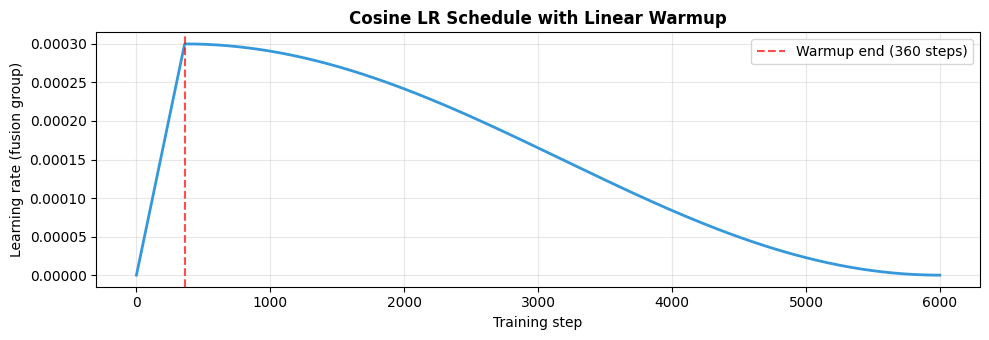

In [13]:
# ── Cell 13: Optimizer & Scheduler ───────────────────────────────────────────

def build_optimizer(model: PathVQAModel, cfg: TrainConfig) -> torch.optim.AdamW:
    """
    Parameter groups with differential learning rates.

    Group 1: backbone params (pretrained, frozen initially) → lr_backbone
    Group 2: fusion + heads (randomly initialized)          → lr_fusion
    """
    backbone_params = (
        list(model.visual_encoder.parameters()) +
        list(model.text_encoder.parameters())
    )
    fusion_params = (
        list(model.fusion.parameters()) +
        list(model.answer_head.parameters())
    )

    param_groups = [
        {
            "params":       [p for p in backbone_params if p.requires_grad],
            "lr":           cfg.lr_backbone,
            "weight_decay": cfg.weight_decay,
            "name":         "backbone",
        },
        {
            "params":       [p for p in fusion_params if p.requires_grad],
            "lr":           cfg.lr_fusion,
            "weight_decay": cfg.weight_decay,
            "name":         "fusion_heads",
        },
    ]

    # Filter empty groups
    param_groups = [g for g in param_groups if len(g["params"]) > 0]

    optimizer = torch.optim.AdamW(param_groups, eps=1e-8, betas=(0.9, 0.999))

    for g in param_groups:
        n_params = sum(p.numel() for p in g["params"])
        print(f"   Param group '{g['name']:15s}': {n_params:>10,} params  lr={g['lr']}")

    return optimizer


def build_scheduler(optimizer, cfg: TrainConfig, num_training_steps: int):
    """
    Cosine LR schedule with linear warmup.

    Warmup: LR linearly increases from 0 → max_lr over warmup_steps
    Decay:  LR follows cosine curve from max_lr → 0 over remaining steps

    This is the standard schedule for transformer fine-tuning (Devlin et al., 2019).
    """
    warmup_steps = int(num_training_steps * cfg.warmup_ratio)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps    = warmup_steps,
        num_training_steps  = num_training_steps,
    )
    print(f"   Scheduler: cosine with warmup")
    print(f"   Total steps: {num_training_steps:,}  Warmup steps: {warmup_steps:,}")
    return scheduler


def visualize_lr_schedule(cfg: TrainConfig, steps_per_epoch: int = 200):
    """Plot the LR schedule before training — verify shape looks correct."""
    total_steps = cfg.num_epochs * steps_per_epoch
    warmup_steps = int(total_steps * cfg.warmup_ratio)

    lrs = []
    for step in range(total_steps):
        if step < warmup_steps:
            lr = cfg.lr_fusion * step / max(1, warmup_steps)
        else:
            progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
            lr = cfg.lr_fusion * max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
        lrs.append(lr)

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(lrs, color="#3498db", linewidth=2)
    ax.axvline(warmup_steps, color="red", ls="--", alpha=0.7, label=f"Warmup end ({warmup_steps} steps)")
    ax.set_xlabel("Training step"); ax.set_ylabel("Learning rate (fusion group)")
    ax.set_title("Cosine LR Schedule with Linear Warmup", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(TCFG.results_dir / "lr_schedule.png", dpi=150)
    plt.show()

visualize_lr_schedule(TCFG)


---
## Section 6: Modular Training Engine

### Key Engineering Features:

1. **AMP (Automatic Mixed Precision)** — float16 activations, float32 params. Cuts VRAM ~50%, speeds up ~2x on Tensor Cores.
2. **Gradient Accumulation** — simulates larger batch size without OOM.
3. **Gradient Clipping** — prevents exploding gradients, common in cross-attention early training.
4. **Early Stopping** — monitors validation accuracy with patience.
5. **Checkpoint Management** — saves best model + latest model to Drive. Resumable on Colab crash.

> **Interview Q:** *What is gradient accumulation and when do you need it?*  
> **A:** Instead of updating after every batch, we accumulate gradients over N batches then update. Effective batch size = batch_size × N. Needed when your GPU can only fit batch_size=8 but the model trains better with 128. Trade-off: N× slower iteration, same final result as true large-batch training.


In [14]:
# ── Cell 14: Training Utilities ──────────────────────────────────────────────

class EarlyStopping:
    """
    Stops training when validation metric stops improving.
    Saves the best model weights to restore after stopping.
    """
    def __init__(self, patience: int = 7, mode: str = "max", min_delta: float = 1e-4):
        self.patience   = patience
        self.mode       = mode
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.best_weights = None
        self.stopped    = False

    def __call__(self, score: float, model: nn.Module) -> bool:
        improved = (
            self.best_score is None or
            (self.mode == "max" and score > self.best_score + self.min_delta) or
            (self.mode == "min" and score < self.best_score - self.min_delta)
        )
        if improved:
            self.best_score   = score
            self.counter      = 0
            self.best_weights = copy.deepcopy(model.state_dict())
            return False  # don't stop
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped = True
                return True   # stop
            return False

    def restore_best(self, model: nn.Module):
        if self.best_weights is not None:
            model.load_state_dict(self.best_weights)
            print(f"✅ Restored best weights (score={self.best_score:.4f})")


class CheckpointManager:
    """
    Saves and loads checkpoints to persistent Drive storage.
    Handles: best model, latest model, and training state.
    """
    def __init__(self, checkpoint_dir: Path):
        self.dir = Path(checkpoint_dir)
        self.dir.mkdir(parents=True, exist_ok=True)

    def save(self, model: nn.Module, optimizer, scheduler,
             epoch: int, metrics: Dict, tag: str = "best"):
        path = self.dir / f"checkpoint_{tag}.pt"
        torch.save({
            "epoch":        epoch,
            "model_state":  model.state_dict(),
            "optim_state":  optimizer.state_dict(),
            "sched_state":  scheduler.state_dict() if scheduler else None,
            "metrics":      metrics,
        }, path)
        print(f"   💾 Checkpoint saved → {path.name}")

    def load(self, model: nn.Module, optimizer=None, scheduler=None,
             tag: str = "best") -> Dict:
        path = self.dir / f"checkpoint_{tag}.pt"
        if not path.exists():
            print(f"   ⚠️  No checkpoint found at {path}")
            return {}
        ckpt = torch.load(path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state"])
        if optimizer and "optim_state" in ckpt:
            optimizer.load_state_dict(ckpt["optim_state"])
        if scheduler and ckpt.get("sched_state"):
            scheduler.load_state_dict(ckpt["sched_state"])
        print(f"   ✅ Checkpoint loaded from {path.name}  (epoch={ckpt['epoch']})")
        return ckpt.get("metrics", {})

    def list_checkpoints(self):
        for p in sorted(self.dir.glob("checkpoint_*.pt")):
            size = p.stat().st_size / 1e6
            print(f"   {p.name}  ({size:.1f} MB)")


class MetricsTracker:
    """Accumulates per-batch metrics and computes epoch-level stats."""

    def __init__(self):
        self.reset()

    def reset(self):
        self._sums    = defaultdict(float)
        self._counts  = defaultdict(int)
        self._correct = {"binary": 0, "open": 0, "total": 0}
        self._total   = {"binary": 0, "open": 0, "total": 0}

    def update(self, losses: Dict[str, torch.Tensor],
               binary_logits: torch.Tensor, open_logits: torch.Tensor,
               targets: torch.Tensor, is_binary: torch.Tensor):

        for k, v in losses.items():
            self._sums[k]   += v.item()
            self._counts[k] += 1

        bin_mask  = is_binary.bool()
        open_mask = ~bin_mask

        if bin_mask.any():
            preds  = binary_logits[bin_mask].argmax(dim=1)
            gts    = targets[bin_mask].clamp(0, 1)
            self._correct["binary"] += (preds == gts).sum().item()
            self._total["binary"]   += bin_mask.sum().item()

        if open_mask.any():
            preds  = open_logits[open_mask].argmax(dim=1)
            gts    = targets[open_mask]
            self._correct["open"] += (preds == gts).sum().item()
            self._total["open"]   += open_mask.sum().item()

        self._correct["total"] += (
            self._correct["binary"] + self._correct.get("open", 0)
        )
        self._total["total"] += is_binary.shape[0]

    def compute(self) -> Dict[str, float]:
        out = {k: v / max(self._counts[k], 1) for k, v in self._sums.items()}
        for split in ["binary", "open", "total"]:
            denom = self._total.get(split, 0)
            out[f"acc_{split}"] = self._correct.get(split, 0) / max(denom, 1)
        return out


print("✅ EarlyStopping, CheckpointManager, MetricsTracker defined.")


✅ EarlyStopping, CheckpointManager, MetricsTracker defined.


In [15]:
# ── Cell 15: Train & Eval Step Functions ─────────────────────────────────────

def train_one_epoch(
    model:      PathVQAModel,
    loader:     DataLoader,
    criterion:  PathVQALoss,
    optimizer:  torch.optim.AdamW,
    scheduler,
    scaler:     GradScaler,
    cfg:        TrainConfig,
    epoch:      int,
) -> Dict[str, float]:
    """
    One full training epoch with:
      - AMP mixed precision
      - Gradient accumulation (every cfg.grad_accum_steps batches)
      - Gradient clipping
      - LR scheduling (step per batch, not per epoch)
    """
    model.train()
    tracker = MetricsTracker()
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        # Move to device
        pixel_values   = batch["image"].to(DEVICE, non_blocking=True)
        input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        targets        = batch["answer_class"].to(DEVICE, non_blocking=True)
        is_binary      = batch["is_binary"].to(DEVICE, non_blocking=True)

        # ── AMP forward pass ─────────────────────────────────────────────────
        with autocast(dtype=torch.float16 if cfg.amp_dtype == "float16"
                      else torch.bfloat16, enabled=cfg.use_amp):
            outputs = model(pixel_values, input_ids, attention_mask, is_binary)
            losses  = criterion(
                outputs["binary_logits"], outputs["open_logits"],
                targets, is_binary,
            )
            # Scale loss for gradient accumulation
            loss = losses["loss"] / cfg.grad_accum_steps

        # ── Backward (scaled for AMP) ─────────────────────────────────────────
        scaler.scale(loss).backward()

        # ── Gradient accumulation: update every N steps ───────────────────────
        if (step + 1) % cfg.grad_accum_steps == 0:
            # Unscale before clipping (required with AMP)
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), cfg.max_grad_norm
            )
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            if scheduler is not None:
                scheduler.step()

        # ── Track metrics ─────────────────────────────────────────────────────
        tracker.update(
            {k: v * cfg.grad_accum_steps for k, v in losses.items()},  # undo scale
            outputs["binary_logits"].detach(),
            outputs["open_logits"].detach(),
            targets, is_binary,
        )

        # ── Progress logging (every 50 steps) ────────────────────────────────
        if (step + 1) % 50 == 0:
            m = tracker.compute()
            lr_now = optimizer.param_groups[-1]["lr"]
            print(f"   Epoch {epoch} | Step {step+1:4d}/{len(loader)} | "
                  f"loss={m['loss']:.4f} | "
                  f"acc_bin={m['acc_binary']:.3f} | "
                  f"acc_open={m['acc_open']:.3f} | "
                  f"lr={lr_now:.2e}")

    return tracker.compute()


@torch.no_grad()
def evaluate(
    model:     PathVQAModel,
    loader:    DataLoader,
    criterion: PathVQALoss,
    cfg:       TrainConfig,
) -> Dict[str, float]:
    """
    Evaluation loop — no gradient computation, no data augmentation.
    Collects predictions for full metric computation in Notebook 3.
    """
    model.eval()
    tracker = MetricsTracker()

    for batch in loader:
        pixel_values   = batch["image"].to(DEVICE, non_blocking=True)
        input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        targets        = batch["answer_class"].to(DEVICE, non_blocking=True)
        is_binary      = batch["is_binary"].to(DEVICE, non_blocking=True)

        with autocast(enabled=cfg.use_amp):
            outputs = model(pixel_values, input_ids, attention_mask, is_binary)
            losses  = criterion(
                outputs["binary_logits"], outputs["open_logits"],
                targets, is_binary,
            )

        tracker.update(losses, outputs["binary_logits"],
                       outputs["open_logits"], targets, is_binary)

    return tracker.compute()


print("✅ train_one_epoch and evaluate functions defined.")


✅ train_one_epoch and evaluate functions defined.


In [16]:
# ── Cell 16: Full Training Loop ──────────────────────────────────────────────

def run_training(
    model:         PathVQAModel,
    dataloaders:   Dict[str, DataLoader],
    criterion:     PathVQALoss,
    cfg:           TrainConfig,
    resume:        bool = False,
) -> Dict[str, List]:
    """
    Master training orchestrator.

    Features:
      - Resume from checkpoint (handles Colab disconnects)
      - Progressive backbone unfreezing
      - EarlyStopping on validation binary accuracy
      - Saves best + latest checkpoints to Drive
      - Returns full training history for plotting
    """
    # ── Setup ─────────────────────────────────────────────────────────────────
    steps_per_epoch = len(dataloaders["train"])
    total_steps     = cfg.num_epochs * steps_per_epoch // cfg.grad_accum_steps

    optimizer  = build_optimizer(model, cfg)
    scheduler  = build_scheduler(optimizer, cfg, total_steps)
    scaler     = GradScaler(enabled=cfg.use_amp)
    stopper    = EarlyStopping(patience=cfg.early_stop_patience, mode="max")
    ckpt_mgr   = CheckpointManager(cfg.checkpoint_dir)

    start_epoch = 0
    history     = defaultdict(list)

    # ── Resume from checkpoint ────────────────────────────────────────────────
    if resume:
        print("🔁 Attempting to resume from checkpoint...")
        ckpt_metrics = ckpt_mgr.load(model, optimizer, scheduler, tag="latest")
        if ckpt_metrics:
            start_epoch = ckpt_metrics.get("epoch", 0) + 1
            print(f"   Resuming from epoch {start_epoch}")

    print(f"\n🚀 Starting training | Epochs: {cfg.num_epochs} | "
          f"Steps/epoch: {steps_per_epoch} | "
          f"Effective batch: {cfg.batch_size * cfg.grad_accum_steps}")
    print(f"   AMP: {cfg.use_amp} | Grad accum: {cfg.grad_accum_steps}x")
    print("=" * 70)

    for epoch in range(start_epoch, cfg.num_epochs):
        epoch_start = time.time()

        # ── Backbone unfreeze schedule ─────────────────────────────────────────
        model.unfreeze_schedule(epoch)

        # ── Train ─────────────────────────────────────────────────────────────
        print(f"\n📈 Epoch {epoch+1}/{cfg.num_epochs}")
        train_metrics = train_one_epoch(
            model, dataloaders["train"], criterion,
            optimizer, scheduler, scaler, cfg, epoch + 1
        )

        # ── Validate ──────────────────────────────────────────────────────────
        val_metrics = evaluate(model, dataloaders["val"], criterion, cfg)

        elapsed = time.time() - epoch_start

        # ── Log ───────────────────────────────────────────────────────────────
        print(f"\n   📊 Epoch {epoch+1} Summary ({elapsed:.0f}s):")
        print(f"      Train | loss={train_metrics['loss']:.4f} | "
              f"acc_bin={train_metrics['acc_binary']:.3f} | "
              f"acc_open={train_metrics['acc_open']:.3f}")
        print(f"      Val   | loss={val_metrics['loss']:.4f} | "
              f"acc_bin={val_metrics['acc_binary']:.3f} | "
              f"acc_open={val_metrics['acc_open']:.3f}")

        for k, v in train_metrics.items():
            history[f"train_{k}"].append(v)
        for k, v in val_metrics.items():
            history[f"val_{k}"].append(v)
        history["epoch"].append(epoch + 1)

        # ── Checkpoint (latest — survives Colab crash) ────────────────────────
        ckpt_mgr.save(model, optimizer, scheduler, epoch,
                      {"epoch": epoch, **val_metrics}, tag="latest")

        # ── Early stopping & best model save ──────────────────────────────────
        monitor_metric = val_metrics["acc_binary"]
        if stopper(monitor_metric, model):
            print(f"\n🛑 Early stopping triggered at epoch {epoch+1}. "
                  f"Best val acc_binary = {stopper.best_score:.4f}")
            stopper.restore_best(model)
            ckpt_mgr.save(model, optimizer, scheduler, epoch,
                          {"epoch": epoch, **val_metrics}, tag="best")
            break
        elif stopper.counter == 0:
            # New best — save immediately
            ckpt_mgr.save(model, optimizer, scheduler, epoch,
                          {"epoch": epoch, **val_metrics}, tag="best")
            print(f"   🏆 New best val acc_binary = {monitor_metric:.4f}")
        else:
            print(f"   ⏳ No improvement ({stopper.counter}/{stopper.patience})")

        # Save history to Drive after each epoch
        with open(cfg.log_dir / "training_history.json", "w") as f:
            json.dump(dict(history), f, indent=2)

    print("\n✅ Training complete.")
    return dict(history)


print("✅ run_training() defined.")
print("\n⚠️  NOTE: Call run_training() only when dataloaders are ready.")
print("   Ensure Notebook 1 has been run (or artifacts loaded below).")


✅ run_training() defined.

⚠️  NOTE: Call run_training() only when dataloaders are ready.
   Ensure Notebook 1 has been run (or artifacts loaded below).


In [17]:
# ── Cell 17: Load DataLoaders (from Notebook 1 or re-build) ─────────────────
# This cell re-creates the dataloaders using the same logic as Nb1.
# If Nb1 artifacts exist, we load config from Drive.

import sys
sys.path.insert(0, str(TCFG.artifact_dir.parent))

from datasets import load_dataset
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPTokenizer
from PIL import Image
import random, warnings

# Re-load vocabulary
if (TCFG.artifact_dir / "answer_vocab.json").exists():
    with open(TCFG.artifact_dir / "answer_vocab.json") as f:
        vdata = json.load(f)
    VOCAB     = vdata["vocab"]
    INV_VOCAB = {int(k): v for k, v in vdata["inv_vocab"].items()}
    print(f"✅ Vocab loaded: {len(VOCAB):,} answers")
else:
    print("⚠️  No vocab artifact — run Notebook 1 first.")
    VOCAB, INV_VOCAB = {"yes": 0, "no": 1, "<UNK>": 2}, {0: "yes", 1: "no", 2: "<UNK>"}

# Re-load tokenizer
cache_dir = str(TCFG.artifact_dir.parent / "cache")
TOKENIZER = CLIPTokenizer.from_pretrained(TCFG.clip_model_name, cache_dir=cache_dir)

# Re-create transforms (identical to Nb1)
TRAIN_TRANSFORM = T.Compose([
    T.Resize((TCFG.image_size, TCFG.image_size)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(180),
    T.ColorJitter(brightness=0.05, contrast=0.05),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                std=(0.26862954, 0.26130258, 0.27577711)),
])
EVAL_TRANSFORM = T.Compose([
    T.Resize((TCFG.image_size, TCFG.image_size)),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                std=(0.26862954, 0.26130258, 0.27577711)),
])

# ── Minimal Dataset class (same interface as Nb1) ─────────────────────────────
class PathVQADataset(Dataset):
    def __init__(self, hf_split, vocab, tokenizer, transform, max_len=77):
        self.hf_split  = hf_split
        self.vocab     = vocab
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len   = max_len
        self._unk      = vocab.get("<UNK>", len(vocab)-1)
    def __len__(self): return len(self.hf_split)
    def __getitem__(self, idx):
        try:
            item = self.hf_split[idx]
            img  = item["image"] if isinstance(item["image"], Image.Image)                    else Image.fromarray(item["image"])
            img  = img.convert("RGB")
            ans  = str(item["answer"]).strip().lower()
            enc  = self.tokenizer(str(item["question"]), max_length=self.max_len,
                                  padding="max_length", truncation=True, return_tensors="pt")
            return {
                "image":          self.transform(img),
                "input_ids":      enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "answer_class":   torch.tensor(self.vocab.get(ans, self._unk), dtype=torch.long),
                "is_binary":      torch.tensor(int(ans in ("yes","no")), dtype=torch.bool),
                "question_text":  str(item["question"]),
                "answer_text":    ans,
            }
        except:
            return {
                "image":          torch.zeros(3, TCFG.image_size, TCFG.image_size),
                "input_ids":      torch.zeros(self.max_len, dtype=torch.long),
                "attention_mask": torch.zeros(self.max_len, dtype=torch.long),
                "answer_class":   torch.tensor(0, dtype=torch.long),
                "is_binary":      torch.tensor(False, dtype=torch.bool),
                "question_text":  "", "answer_text": "",
            }

def collate_fn(batch):
    out = {k: torch.stack([b[k] for b in batch])
           for k in ["image","input_ids","attention_mask","answer_class","is_binary"]}
    out["question_text"] = [b["question_text"] for b in batch]
    out["answer_text"]   = [b["answer_text"]   for b in batch]
    return out

# Load HF dataset
print("\n📥 Loading PathVQA dataset...")
try:
    HF_DATASET = load_dataset("flaviagiammarino/path-vqa",
                              cache_dir=cache_dir, trust_remote_code=True)
    DATALOADERS = {}
    split_cfg = [
        ("train",      "train",      TRAIN_TRANSFORM, True,  True),
        ("val",        "validation", EVAL_TRANSFORM,  False, False),
        ("test",       "test",       EVAL_TRANSFORM,  False, False),
    ]
    for name, hf_key, tfm, shuffle, drop in split_cfg:
        ds = PathVQADataset(HF_DATASET[hf_key], VOCAB, TOKENIZER, tfm)
        DATALOADERS[name] = DataLoader(
            ds, batch_size=TCFG.batch_size, shuffle=shuffle,
            num_workers=2, pin_memory=torch.cuda.is_available(),
            collate_fn=collate_fn, drop_last=drop,
        )
        print(f"   {name:8s}: {len(ds):,} samples | {len(DATALOADERS[name]):,} batches")
    print("\n✅ DataLoaders ready.")
except Exception as e:
    print(f"⚠️  Dataset load failed: {e}")
    print("   → Run Notebook 1 first to cache the dataset.")
    DATALOADERS = None


✅ Vocab loaded: 2,003 answers


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'flaviagiammarino/path-vqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'flaviagiammarino/path-vqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.



📥 Loading PathVQA dataset...
   train   : 19,654 samples | 614 batches
   val     : 6,259 samples | 196 batches
   test    : 6,719 samples | 210 batches

✅ DataLoaders ready.


In [18]:
# # ── Cell 18: Launch Training ──────────────────────────────────────────────────
# # ⚠️  This cell starts training. On T4 Colab:
# #    - 1 epoch ≈ 15-20 minutes (full PathVQA)
# #    - Early stopping typically triggers at epoch 12-18
# #    - Total training ≈ 3-5 hours
# #    - Use Colab Pro or run overnight with Drive checkpointing

# if DATALOADERS is None:
#     print("❌ Cannot train — dataloaders not ready. Run the dataset cell above.")
# else:
#     print("🚀 Launching PathVQA training...")
#     print(f"   Checkpoint dir: {TCFG.checkpoint_dir}")
#     print(f"   Resume:         False (set True to resume from Drive checkpoint)")
#     print()

#     HISTORY = run_training(
#         model        = MODEL,
#         dataloaders  = DATALOADERS,
#         criterion    = CRITERION,
#         cfg          = TCFG,
#         resume       = False,   # ← set True if Colab crashed mid-run
#     )
# ── Cell 18: Launch Training (RESUME MODE) ───────────────────────────────────

if DATALOADERS is None:
    print("❌ Cannot train — dataloaders not ready. Run the dataset cell above.")
else:
    print("🚀 Launching PathVQA training...")
    print(f"   Checkpoint dir: {TCFG.checkpoint_dir}")
    print(f"   Resume:         True")
    print()

    # 1. Load the history from yesterday so the charts don't reset
    history_path = TCFG.log_dir / "training_history.json"
    if history_path.exists():
        with open(history_path, "r") as f:
            PREVIOUS_HISTORY = json.load(f)
            print(f"   ✅ Loaded previous history for {len(PREVIOUS_HISTORY['epoch'])} epochs.")
    else:
        PREVIOUS_HISTORY = None

    # 2. Start training with resume=True
    NEW_HISTORY = run_training(
        model        = MODEL,
        dataloaders  = DATALOADERS,
        criterion    = CRITERION,
        cfg          = TCFG,
        resume       = True,   # <--- THIS TELLS YOUR CODE TO LOAD EPOCH 8
    )

    # 3. Stitch yesterday's history and today's history together for the graphs
    if PREVIOUS_HISTORY:
        for k in NEW_HISTORY.keys():
            PREVIOUS_HISTORY[k].extend(NEW_HISTORY[k])
        HISTORY = PREVIOUS_HISTORY
        # Re-save the combined history
        with open(history_path, "w") as f:
            json.dump(HISTORY, f, indent=2)
    else:
        HISTORY = NEW_HISTORY

🚀 Launching PathVQA training...
   Checkpoint dir: /content/drive/MyDrive/PathVQA_Project/checkpoints
   Resume:         True

   ✅ Loaded previous history for 10 epochs.
   Param group 'backbone       ':  1,051,648 params  lr=5e-05
   Param group 'fusion_heads   ': 10,094,805 params  lr=0.0003
   Scheduler: cosine with warmup
   Total steps: 4,605  Warmup steps: 276
🔁 Attempting to resume from checkpoint...
   ✅ Checkpoint loaded from checkpoint_latest.pt  (epoch=9)
   Resuming from epoch 10

🚀 Starting training | Epochs: 30 | Steps/epoch: 614 | Effective batch: 128
   AMP: True | Grad accum: 4x

📈 Epoch 11/30
   Epoch 11 | Step   50/614 | loss=19.4889 | acc_bin=0.859 | acc_open=0.187 | lr=2.41e-04
   Epoch 11 | Step  100/614 | loss=19.2721 | acc_bin=0.870 | acc_open=0.189 | lr=2.40e-04
   Epoch 11 | Step  150/614 | loss=19.2239 | acc_bin=0.866 | acc_open=0.176 | lr=2.39e-04
   Epoch 11 | Step  200/614 | loss=19.3441 | acc_bin=0.871 | acc_open=0.172 | lr=2.38e-04
   Epoch 11 | Step  2

---
## Section 7: Training Curves & Diagnostics

Run this section after training completes (or after loading history from Drive).


✅ History loaded: 26 epochs


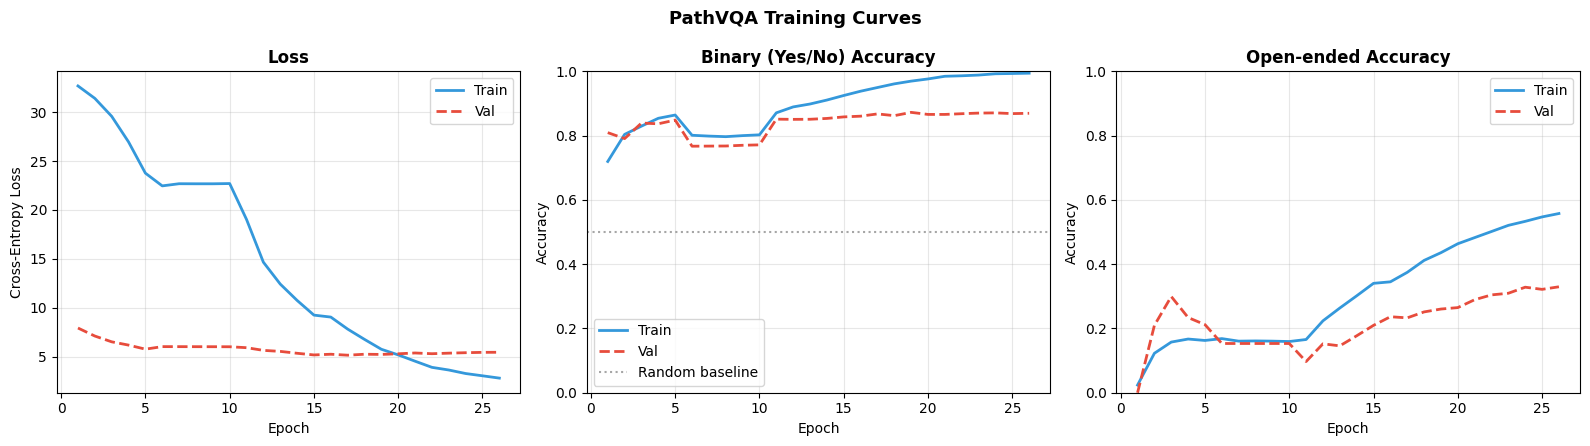


📊 Training Summary:
   Best val binary acc : 0.8723 at epoch 19
   Final train loss    : 2.8198
   Final val loss      : 5.4601
   Overfit gap         : 0.1248 ⚠️ (>0.1 suggests overfitting)


In [20]:
# ── Cell 19: Load History & Plot Training Curves ──────────────────────────────

history_path = TCFG.log_dir / "training_history.json"

if history_path.exists():
    with open(history_path) as f:
        HISTORY = json.load(f)
    print(f"✅ History loaded: {len(HISTORY['epoch'])} epochs")
else:
    print("⚠️  No training history found. Run training first.")
    # Create dummy history for layout verification
    HISTORY = {
        "epoch":           list(range(1, 6)),
        "train_loss":      [1.2, 1.0, 0.85, 0.75, 0.68],
        "val_loss":        [1.3, 1.05, 0.90, 0.80, 0.73],
        "train_acc_binary":[0.52, 0.58, 0.63, 0.67, 0.70],
        "val_acc_binary":  [0.50, 0.55, 0.60, 0.64, 0.67],
        "train_acc_open":  [0.10, 0.18, 0.24, 0.29, 0.33],
        "val_acc_open":    [0.09, 0.16, 0.22, 0.26, 0.30],
    }

def plot_training_curves(history: Dict):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    epochs = history["epoch"]

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train", color="#3498db", lw=2)
    axes[0].plot(epochs, history["val_loss"],   label="Val",   color="#e74c3c", lw=2, ls="--")
    axes[0].set_title("Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Binary accuracy
    axes[1].plot(epochs, history["train_acc_binary"], label="Train", color="#3498db", lw=2)
    axes[1].plot(epochs, history["val_acc_binary"],   label="Val",   color="#e74c3c", lw=2, ls="--")
    axes[1].axhline(0.5, color="gray", ls=":", label="Random baseline", alpha=0.7)
    axes[1].set_title("Binary (Yes/No) Accuracy", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Open-ended accuracy
    axes[2].plot(epochs, history["train_acc_open"], label="Train", color="#3498db", lw=2)
    axes[2].plot(epochs, history["val_acc_open"],   label="Val",   color="#e74c3c", lw=2, ls="--")
    axes[2].set_title("Open-ended Accuracy", fontweight="bold")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy")
    axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle("PathVQA Training Curves", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(TCFG.results_dir / "training_curves.png", dpi=150)
    plt.show()

    # Diagnostics
    best_ep  = int(np.argmax(history["val_acc_binary"])) + 1
    best_acc = max(history["val_acc_binary"])
    print(f"\n📊 Training Summary:")
    print(f"   Best val binary acc : {best_acc:.4f} at epoch {best_ep}")
    print(f"   Final train loss    : {history['train_loss'][-1]:.4f}")
    print(f"   Final val loss      : {history['val_loss'][-1]:.4f}")
    overfit_gap = history['train_acc_binary'][-1] - history['val_acc_binary'][-1]
    print(f"   Overfit gap         : {overfit_gap:.4f}",
          "⚠️ (>0.1 suggests overfitting)" if overfit_gap > 0.1 else "✅ (acceptable)")

plot_training_curves(HISTORY)


---
## Section 8: Export Model Artifacts for Notebook 3


In [21]:
# ── Cell 20: Export Final Artifacts ──────────────────────────────────────────

# 1. Save model config
tcfg_dict = {k: str(v) if isinstance(v, Path) else v
             for k, v in TCFG.__dict__.items()}
with open(TCFG.artifact_dir / "train_config.json", "w") as f:
    json.dump(tcfg_dict, f, indent=2, default=str)
print("✅ train_config.json saved")

# 2. Export best checkpoint path reference
best_ckpt = TCFG.checkpoint_dir / "checkpoint_best.pt"
if best_ckpt.exists():
    print(f"✅ Best checkpoint: {best_ckpt}  ({best_ckpt.stat().st_size/1e6:.1f} MB)")
else:
    print("⚠️  No best checkpoint yet — run training first.")

# 3. Verify all artifacts for Nb3
print("\n📦 Artifacts for Notebook 3:")
required = [
    TCFG.artifact_dir / "answer_vocab.json",
    TCFG.artifact_dir / "train_config.json",
    TCFG.checkpoint_dir / "checkpoint_best.pt",
    TCFG.log_dir / "training_history.json",
]
for p in required:
    status = "✅" if p.exists() else "❌ MISSING"
    print(f"   {status}  {p.name}")

print("\n🚀 Ready for Notebook 3: Evaluation, Explainability & Inference")


✅ train_config.json saved
✅ Best checkpoint: /content/drive/MyDrive/PathVQA_Project/checkpoints/checkpoint_best.pt  (733.3 MB)

📦 Artifacts for Notebook 3:
   ✅  answer_vocab.json
   ✅  train_config.json
   ✅  checkpoint_best.pt
   ✅  training_history.json

🚀 Ready for Notebook 3: Evaluation, Explainability & Inference


---
## 📋 Summary & Notebook 3 Preview

### What we built in Notebook 2:

| Component | Architecture Choice | Why |
|---|---|---|
| Visual backbone | CLIP ViT-B/32 frozen | Strong patch-level features, no GPU budget for full fine-tune |
| Text backbone | CLIP text encoder frozen | Consistent embedding space with image encoder |
| Fusion | 2-block cross-attention | Text queries image patches — question-conditioned visual features |
| Answer head | Hybrid binary + open | Calibration, safety, loss stability |
| Loss | Weighted CE (optional Focal) | Handles extreme class imbalance |
| Training | AMP + grad accum + cosine LR | T4 memory constraints + stable training |
| Checkpointing | Best + Latest on Drive | Survives Colab crashes |

---

### 🎤 Interview Questions Covered by This Notebook

1. **Why use patch-level features instead of CLS-pooled for cross-attention?**  
   → CLS collapses spatial information. Cross-attention over 197 patches lets the model attend to specific tissue regions based on the question.

2. **Explain the cross-attention mechanism here.**  
   → Q=text tokens, K=V=image patches. `softmax(QKᵀ/√d)·V` produces question-conditioned visual summaries. Each text token can attend to any image patch.

3. **Why two separate answer heads?**  
   → Calibration, clinical safety, loss scale stability. Binary path gives auditable yes/no confidence; open-ended path handles the V-class problem.

4. **What is gradient accumulation and what problem does it solve?**  
   → Accumulates gradients across N mini-batches before stepping. Simulates batch_size×N without requiring the VRAM for a large batch.

5. **Why use different LRs for backbone vs. fusion layers?**  
   → Pretrained backbone weights need tiny updates to avoid catastrophic forgetting. Randomly-initialized fusion layers need large LR to converge from scratch.

6. **What does AMP do and what are its risks?**  
   → Runs forward pass in float16 (saves VRAM, faster on Tensor Cores), keeps master weights in float32. Risk: float16 underflow with small gradients — mitigated by GradScaler.

7. **How does early stopping prevent overfitting in medical AI?**  
   → Monitors validation metric; stops training when improvement stagnates. Restores best weights. In medical AI, overfitted models can appear confident on wrong answers — dangerous.
